Saving House Price Prediction Dataset.csv to House Price Prediction Dataset (1).csv
Columns in dataset: Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


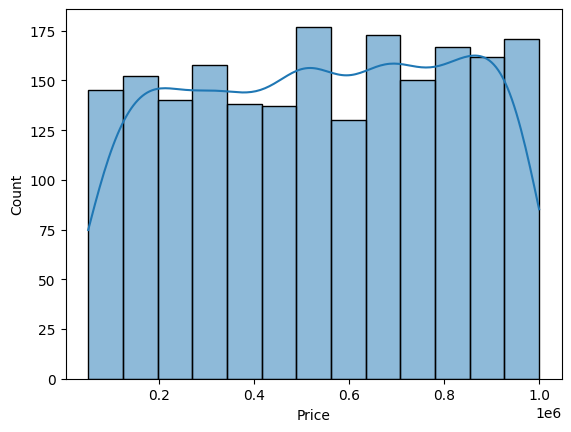

Ridge()

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor

# Step 2: Upload Dataset
from google.colab import files
uploaded = files.upload()

# Load CSV (adjust file name if needed)
df = pd.read_csv(list(uploaded.keys())[0])

# Step 3: Clean Column Names
df.columns = df.columns.str.strip()  # remove any extra spaces
print("Columns in dataset:", df.columns)

# Step 4: Exploratory Data Analysis
sns.histplot(df["Price"], kde=True)
plt.show()

# Step 5: Feature Engineering
# Log-transform target
df["Price"] = np.log1p(df["Price"])

# Create 'HouseAge' feature (assuming your dataset has 'YearBuilt')
if "YearBuilt" in df.columns:
    df["HouseAge"] = 2026 - df["YearBuilt"]
else:
    df["HouseAge"] = 0  # If year not available, use 0

# Updated feature list based on your dataset
features = ["Area", "Bedrooms", "Bathrooms", "Floors", "Garage", "HouseAge"]
X = df[features]
y = df["Price"]

# Identify categorical and numerical features
categorical_features = ["Garage"]
numerical_features = [col for col in features if col not in categorical_features]

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale Features (for linear models) and apply one-hot encoding
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Step 8: Model Training
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)